# CV Peak Analyzer

## 1. Setup

In [138]:
import os
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.signal import find_peaks

INPUT_DIR = 'lab_input'
CSV_DIR = 'csv_output'
PLOT_DIR = 'plot_output'
RESULTS_CSV = 'peak_results.csv'

os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

## 2. File Parsing

In [139]:
def parse_dy20(path):
    with open(path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
    start, end = None, len(lines)
    for i, line in enumerate(lines):
        if 'Data start from here' in line:
            start = i
        elif 'End of data' in line and start is not None:
            end = i
            break
    if start is None:
        raise ValueError(f'No data block found in {path}')
    rows = []
    for line in lines[start + 1:end]:
        line = line.strip()
        if not line or 'Potential' in line:
            continue
        parts = re.split(r'[\s,]+', line)
        if len(parts) >= 2:
            try:
                rows.append((float(parts[0]), float(parts[1])))
            except ValueError:
                continue
    return pd.DataFrame(rows, columns=['x', 'y'])


def parse_csv(path):
    raw = pd.read_csv(path, sep=None, engine='python')
    v_col = [c for c in raw.columns
             if 'Working Electrode' in c and 'NHE' not in c and 'vs' not in c.lower()][0]
    i_col = [c for c in raw.columns if c.strip() == 'Current (A)'][0]
    df = raw[[v_col, i_col]].copy()
    df.columns = ['x', 'y']
    return df.dropna().reset_index(drop=True)


def load(path):
    return parse_csv(path) if path.lower().endswith('.csv') else parse_dy20(path)

## 3. Cell sweeping and peak detection

In [140]:
def split_sweeps(df):
    idx_min = df['x'].idxmin()
    idx_max = df['x'].idxmax()
    n = len(df)
    min_interior = 0 < idx_min < n - 1
    max_interior = 0 < idx_max < n - 1
    if min_interior and not max_interior:
        turn = idx_min
    elif max_interior and not min_interior:
        turn = idx_max
    elif min_interior and max_interior:
        d_min = min(idx_min, n - 1 - idx_min)
        d_max = min(idx_max, n - 1 - idx_max)
        turn = idx_min if d_min > d_max else idx_max
    else:
        turn = n // 2
    return df.iloc[:turn + 1].reset_index(drop=True), df.iloc[turn:].reset_index(drop=True)


def _smooth(y, window=15):
    if len(y) < window:
        return y
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode='same')


def find_peak(sweep, direction, edge_frac=0.05, min_prominence_frac=0.05):
    n = len(sweep)
    if n < 20:
        return None
    trim = max(1, int(n * edge_frac))
    inner = sweep.iloc[trim:n - trim].reset_index(drop=False)
    y_raw = inner['y'].values
    y_smooth = _smooth(y_raw, window=max(5, len(y_raw) // 100))
    baseline = np.linspace(y_smooth[0], y_smooth[-1], len(y_smooth))
    y_flat = y_smooth - baseline
    signal = y_flat if direction == 'max' else -y_flat
    y_range = signal.max() - signal.min()
    if y_range <= 0:
        return None
    min_prom = y_range * min_prominence_frac
    peaks, props = find_peaks(signal, prominence=min_prom)
    if len(peaks) == 0:
        return None
    best = peaks[np.argmax(props['prominences'])]
    return int(inner.loc[best, 'index'])


def find_cv_peaks(fwd, rev):
    candidates_a = []
    for sweep, label in [(fwd, 'fwd'), (rev, 'rev')]:
        idx = find_peak(sweep, 'max')
        if idx is not None:
            candidates_a.append((sweep, idx, label))

    candidates_c = []
    for sweep, label in [(fwd, 'fwd'), (rev, 'rev')]:
        idx = find_peak(sweep, 'min')
        if idx is not None:
            candidates_c.append((sweep, idx, label))

    def pick_best(cands, direction):
        if not cands:
            return None
        best = None
        best_score = -np.inf
        for sweep, idx, label in cands:
            y = sweep['y'].values
            base = np.linspace(y[0], y[-1], len(y))
            height = (y[idx] - base[idx]) if direction == 'max' else (base[idx] - y[idx])
            if height > best_score:
                best_score = height
                best = (sweep, idx, label)
        return best

    return pick_best(candidates_a, 'max'), pick_best(candidates_c, 'min')

## 4. Tangent fitting

In [141]:

def plot_result(df, res, title, save_path):
    x_line = np.linspace(df['x'].min(), df['x'].max(), 200)
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.plot(df['x'], df['y'], 'r', linewidth=1)
    ax.plot(x_line, res['fwd_slope'] * x_line + res['fwd_int'], color='orange', linewidth=1.5)
    ax.plot(x_line, res['rev_slope'] * x_line + res['rev_int'], color='orange', linewidth=1.5)
    ax.vlines(res['anodic_bar_x'], res['fwd_at_peak'], res['i_pa'], colors='blue', linewidth=2)
    ax.vlines(res['e_pc'], res['i_pc'], res['rev_at_peak'], colors='blue', linewidth=2)
    ax.annotate(f"i_pa = {res['i_pa']:.3e}", xy=(res['e_pa'], res['i_pa']), xytext=(10, 10),
                textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
    ax.annotate(f"i_pc = {res['i_pc']:.3e}", xy=(res['e_pc'], res['i_pc']), xytext=(10, -15),
                textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
    ax.annotate(f"h_a = {res['anodic_height']:.3e}",
                xy=(res['anodic_bar_x'], (res['i_pa'] + res['fwd_at_peak']) / 2),
                xytext=(15, 0), textcoords='offset points', fontsize=9, color='blue',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='blue'))
    ax.annotate(f"h_c = {res['cathodic_height']:.3e}",
                xy=(res['e_pc'], (res['i_pc'] + res['rev_at_peak']) / 2),
                xytext=(15, 0), textcoords='offset points', fontsize=9, color='blue',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='blue'))
    ax.axhline(0, color='green', linewidth=1)
    pad_x = (df['x'].max() - df['x'].min()) * 0.05
    ax.set_xlim(df['x'].max() + pad_x, df['x'].min() - pad_x)
    pad_y = (df['y'].max() - df['y'].min()) * 0.15
    ax.set_ylim(df['y'].min() - pad_y, df['y'].max() + pad_y)
    ax.set_xlabel('Potential (V)')
    ax.set_ylabel('Current (A)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    plt.tight_layout()
    plt.savefig(save_path, dpi=100)
    plt.close(fig)

## 5. Perform analysis

In [142]:
def analyze(df):
    fwd, rev = split_sweeps(df)
    a, c = find_cv_peaks(fwd, rev)

    if a is None:
        a = (fwd, int(fwd['y'].idxmax()), 'fwd')
    if c is None:
        c = (rev, int(rev['y'].idxmin()), 'rev')

    a_sweep, a_idx, a_label = a
    c_sweep, c_idx, c_label = c

    i_pa = a_sweep.loc[a_idx, 'y']
    e_pa = a_sweep.loc[a_idx, 'x']
    i_pc = c_sweep.loc[c_idx, 'y']
    e_pc = c_sweep.loc[c_idx, 'x']

    a_slope, a_int = tangent_at_range(a_sweep, *pick_tangent_window(a_sweep, e_pa))
    c_slope, c_int = tangent_at_range(c_sweep, *pick_tangent_window(c_sweep, e_pc))

    a_at_peak = a_slope * e_pa + a_int
    c_at_peak = c_slope * e_pc + c_int

    anodic_height = i_pa - a_at_peak
    anodic_bar_x = e_pa

    return {
        'i_pa': i_pa, 'e_pa': e_pa,
        'i_pc': i_pc, 'e_pc': e_pc,
        'anodic_height': anodic_height,
        'cathodic_height': c_at_peak - i_pc,
        'a_slope': a_slope, 'a_int': a_int,
        'c_slope': c_slope, 'c_int': c_int,
        'a_at_peak': a_at_peak, 'c_at_peak': c_at_peak,
        'anodic_bar_x': anodic_bar_x,
        'a_label': a_label, 'c_label': c_label,
    }

## 6. Plotting

In [143]:
def plot_result(df, res, title, save_path):
    x_line = np.linspace(df['x'].min(), df['x'].max(), 200)

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.plot(df['x'], df['y'], 'r', linewidth=1)
    ax.plot(x_line, res['a_slope'] * x_line + res['a_int'],
            color='orange', linewidth=1.5)
    ax.plot(x_line, res['c_slope'] * x_line + res['c_int'],
            color='orange', linewidth=1.5)

    ax.vlines(res['anodic_bar_x'], res['a_at_peak'], res['i_pa'],
              colors='blue', linewidth=2)
    ax.vlines(res['e_pc'], res['i_pc'], res['c_at_peak'],
              colors='blue', linewidth=2)

    ax.annotate(f"i_pa = {res['i_pa']:.3e}", xy=(res['e_pa'], res['i_pa']),
                xytext=(10, 10), textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
    ax.annotate(f"i_pc = {res['i_pc']:.3e}", xy=(res['e_pc'], res['i_pc']),
                xytext=(10, -15), textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
    ax.annotate(f"h_a = {res['anodic_height']:.3e}",
                xy=(res['anodic_bar_x'], (res['i_pa'] + res['a_at_peak']) / 2),
                xytext=(15, 0), textcoords='offset points', fontsize=9, color='blue',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='blue'))
    ax.annotate(f"h_c = {res['cathodic_height']:.3e}",
                xy=(res['e_pc'], (res['i_pc'] + res['c_at_peak']) / 2),
                xytext=(15, 0), textcoords='offset points', fontsize=9, color='blue',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='blue'))

    ax.axhline(0, color='green', linewidth=1)

    pad_x = (df['x'].max() - df['x'].min()) * 0.05
    ax.set_xlim(df['x'].max() + pad_x, df['x'].min() - pad_x)

    y_sorted = np.sort(df['y'].values)
    n = len(y_sorted)
    lo_cut = y_sorted[max(0, int(n * 0.01))]
    hi_cut = y_sorted[min(n - 1, int(n * 0.99))]
    lo_cut = min(lo_cut, res['i_pc'], res['a_at_peak'], res['c_at_peak'])
    hi_cut = max(hi_cut, res['i_pa'], res['a_at_peak'], res['c_at_peak'])
    pad_y = (hi_cut - lo_cut) * 0.15 if hi_cut > lo_cut else 1e-6
    ax.set_ylim(lo_cut - pad_y, hi_cut + pad_y)

    ax.set_xlabel('Potential (V)')
    ax.set_ylabel('Current (A)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    plt.tight_layout()
    plt.savefig(save_path, dpi=100)
    plt.show()

## 7. Run the pipeline

Parsing Exp 1...
Parsing Exp 10...
Parsing Exp 11...
Parsing Exp 12...
Parsing Exp 13...
Parsing Exp 14...
Parsing Exp 15...
Parsing Exp 16...
Parsing Exp 17...
Parsing Exp 2...
Parsing Exp 3...
Parsing Exp 4...
Parsing Exp 5...
Parsing Exp 6...
Parsing Exp 7...
Parsing Exp 8...
Parsing Exp 9...
Parsing exp 18...
Parsing exp 19...
Analyzing Exp 1...


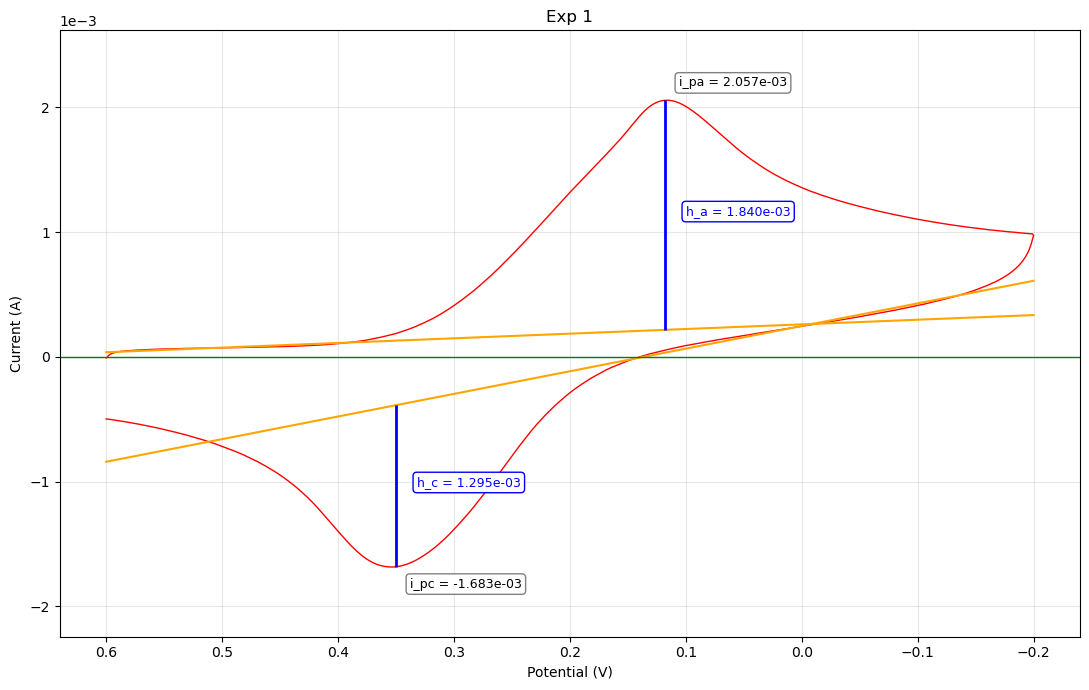

Analyzing Exp 10...


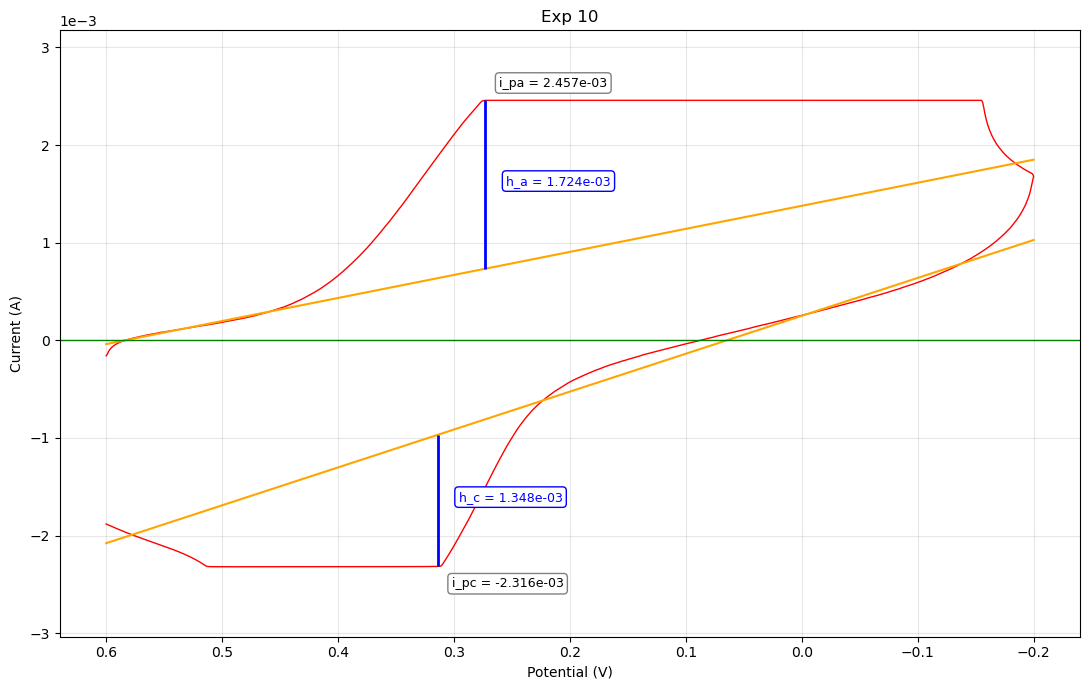

Analyzing Exp 11...


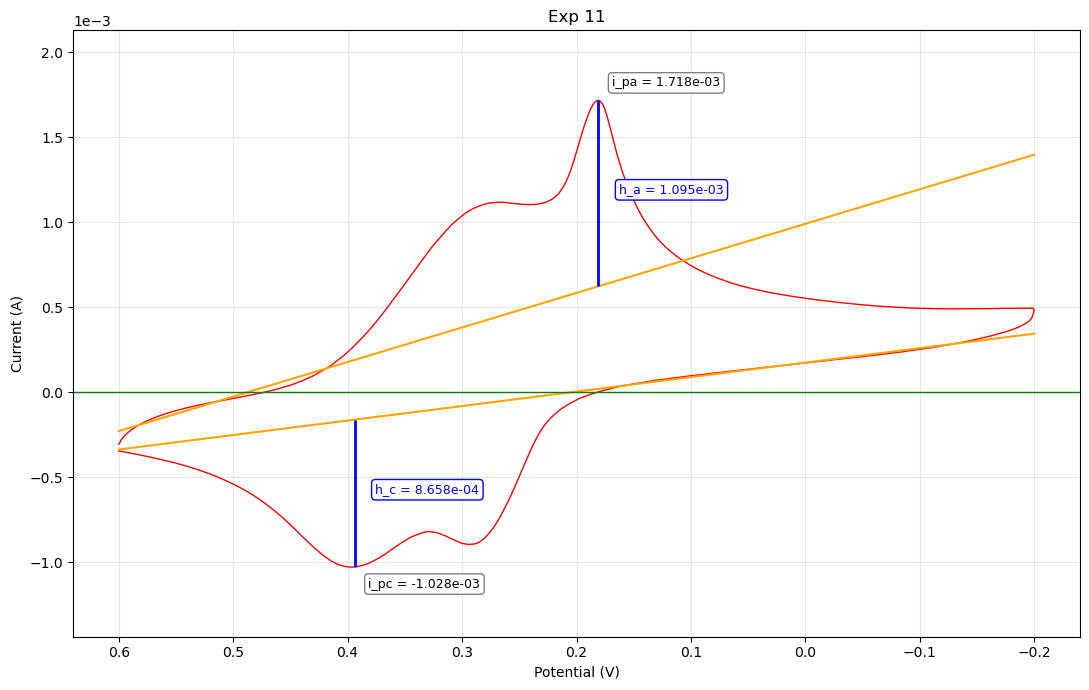

Analyzing Exp 12...


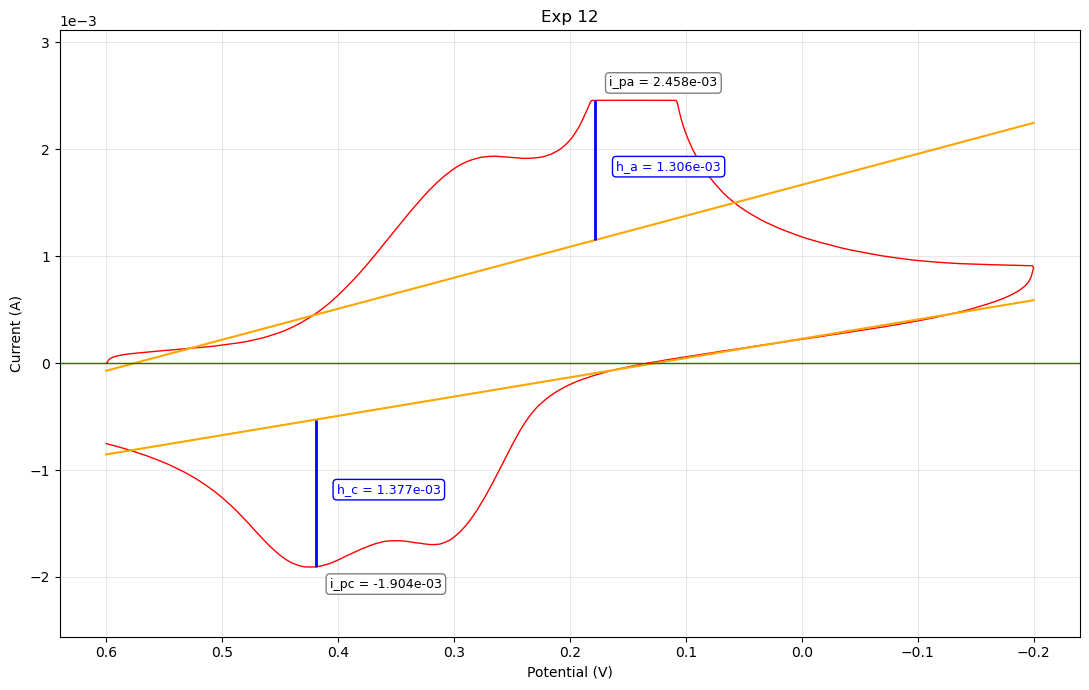

Analyzing Exp 13...


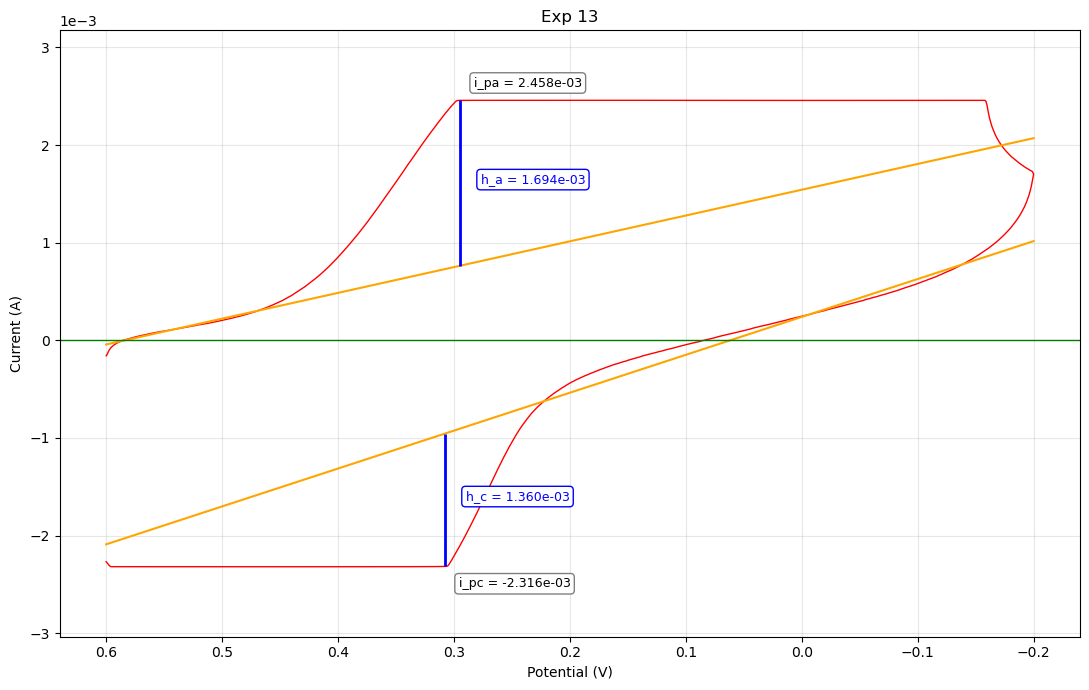

Analyzing Exp 14...


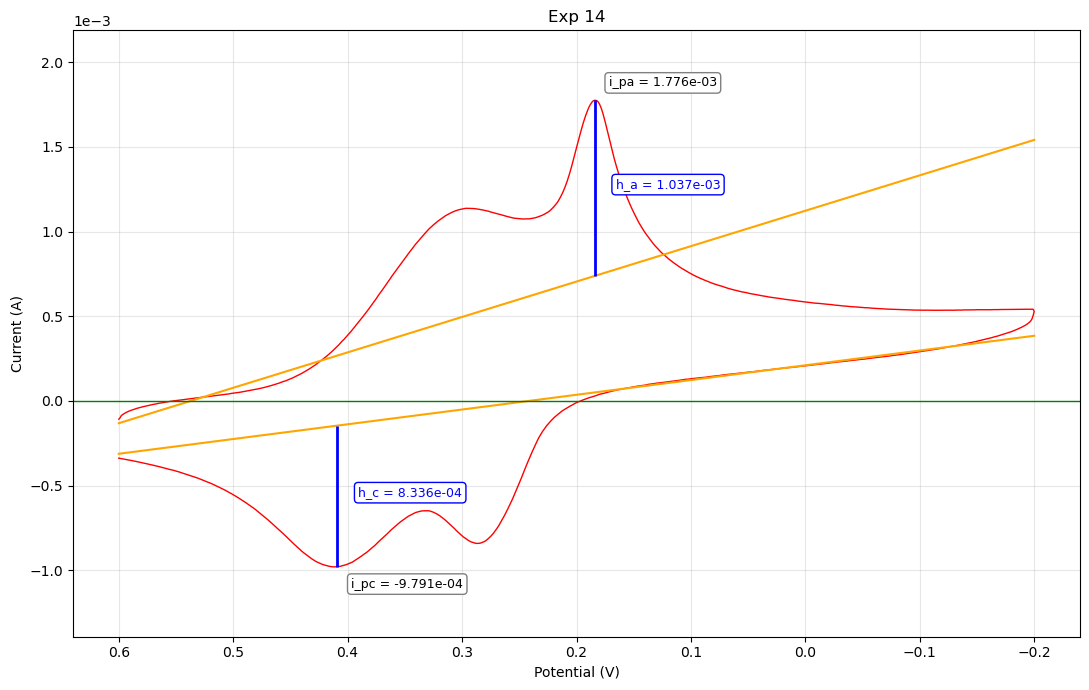

Analyzing Exp 15...


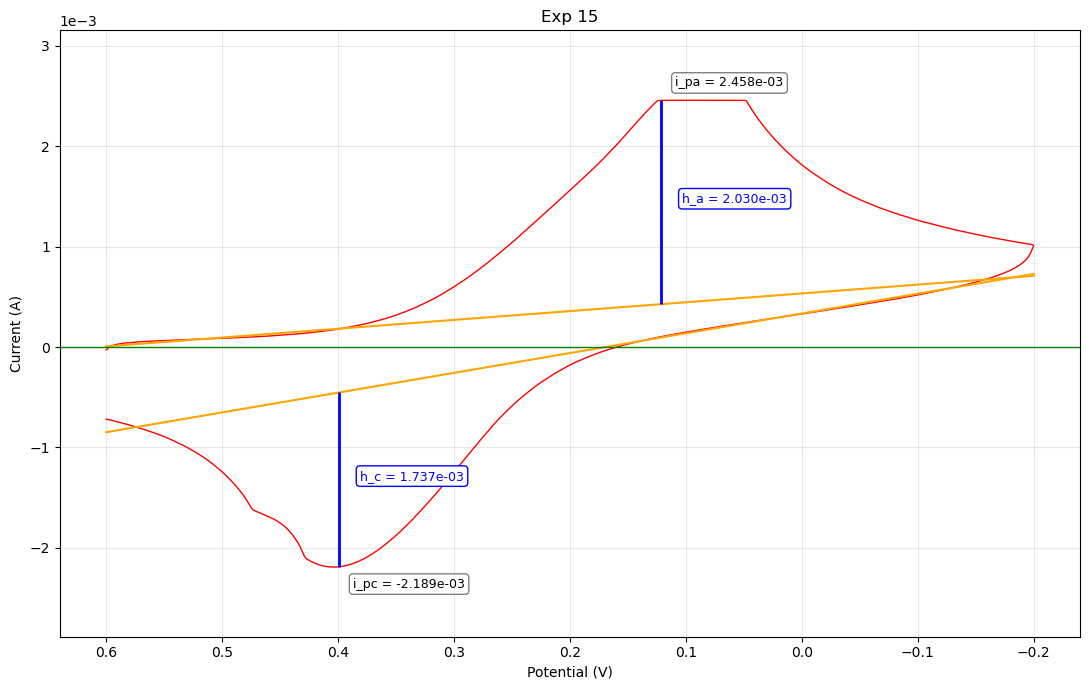

Analyzing Exp 16...


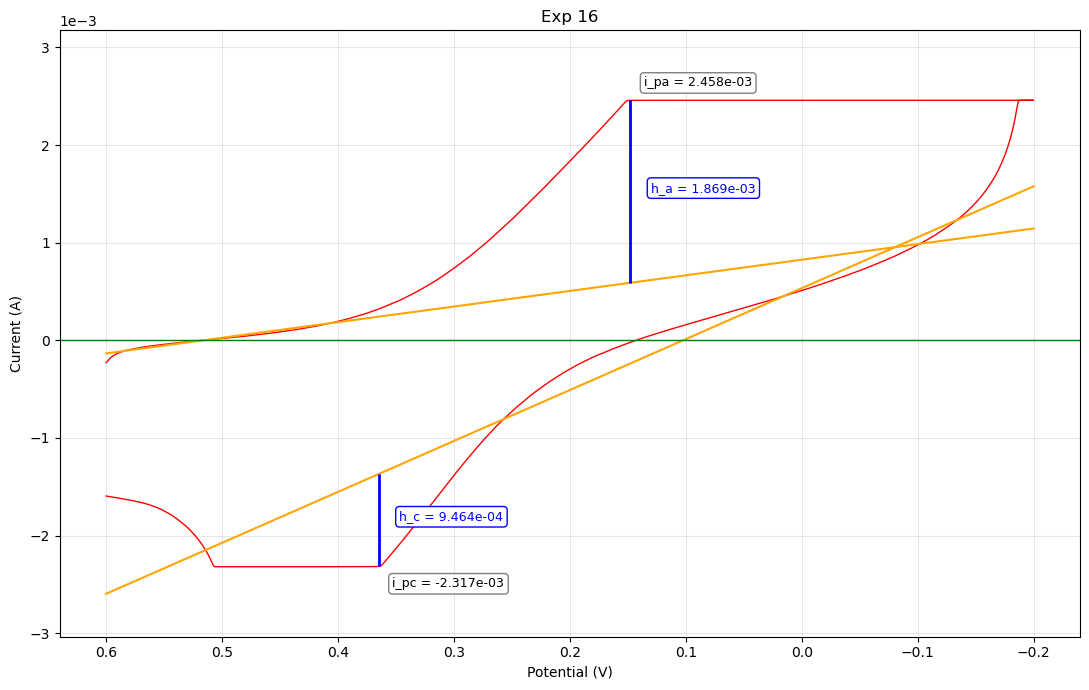

Analyzing Exp 17...


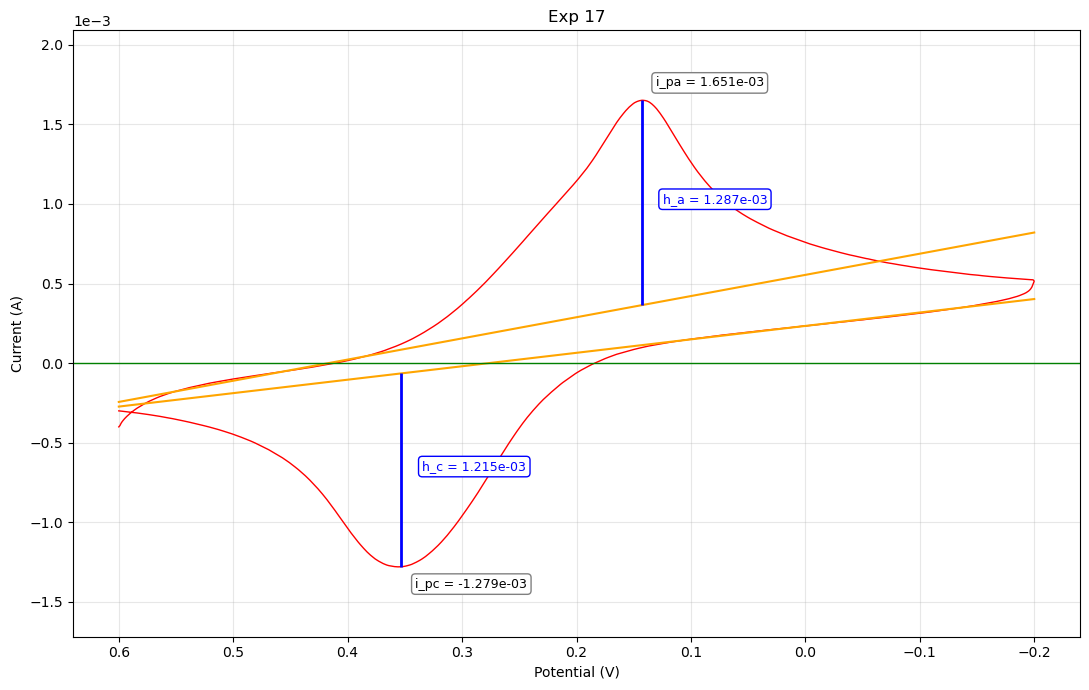

Analyzing Exp 2...


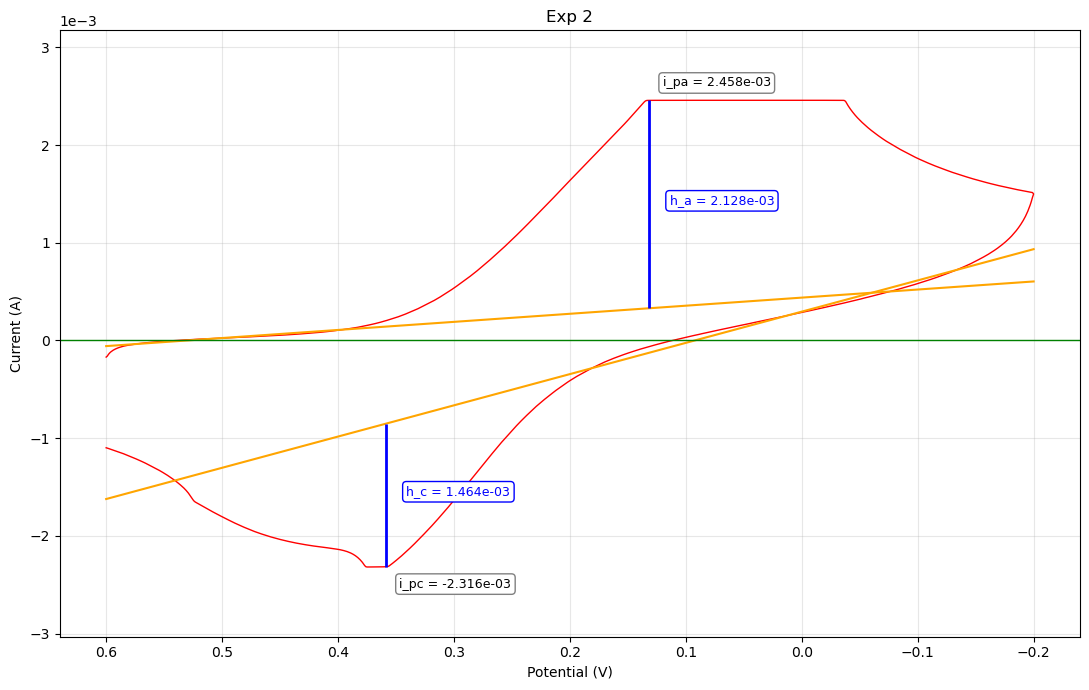

Analyzing Exp 3...


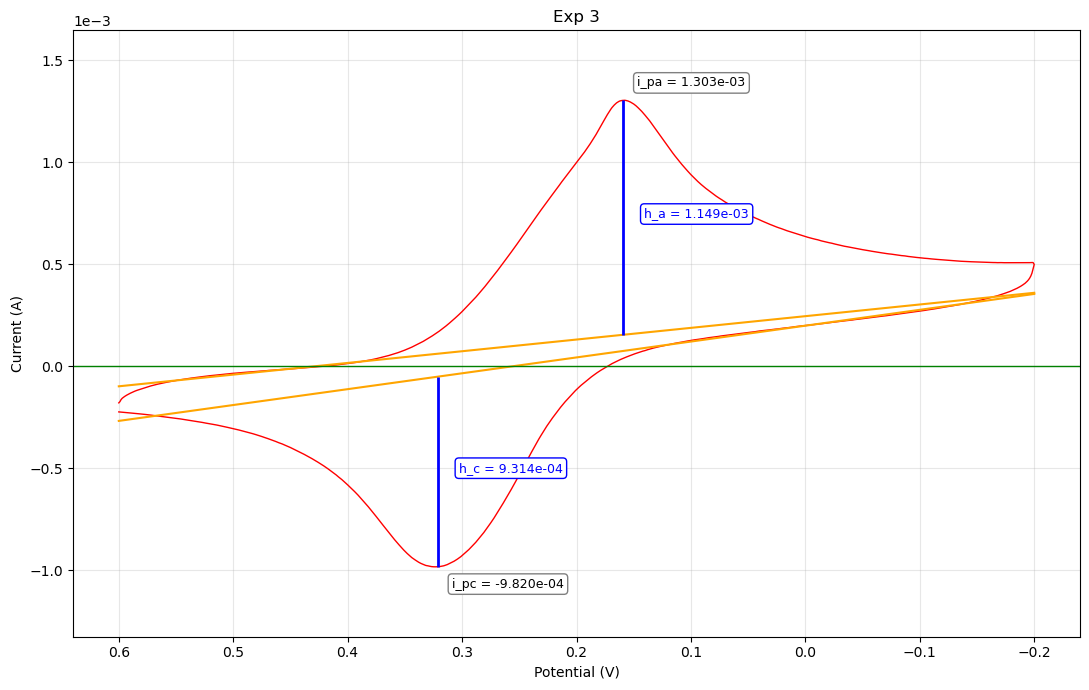

Analyzing Exp 4...


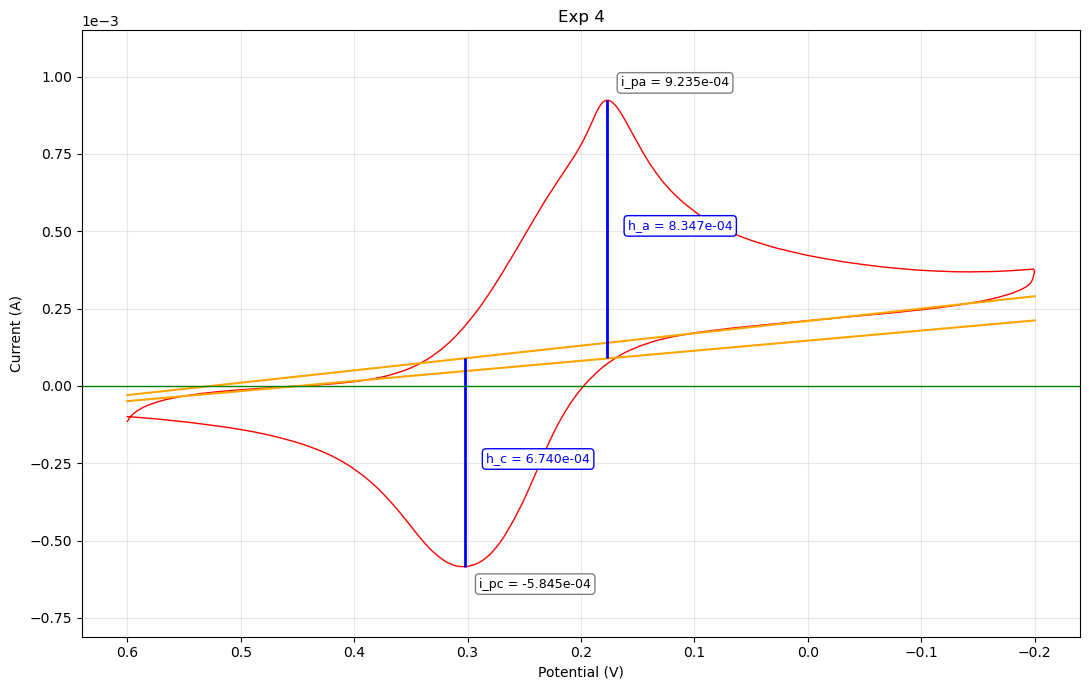

Analyzing Exp 5...


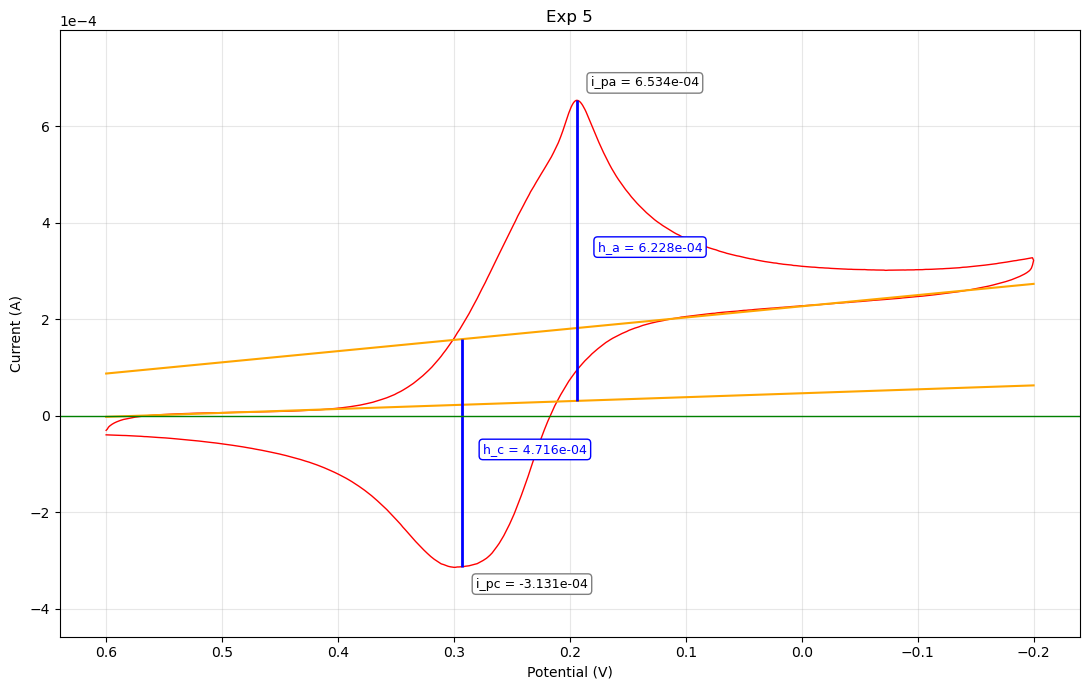

Analyzing Exp 6...


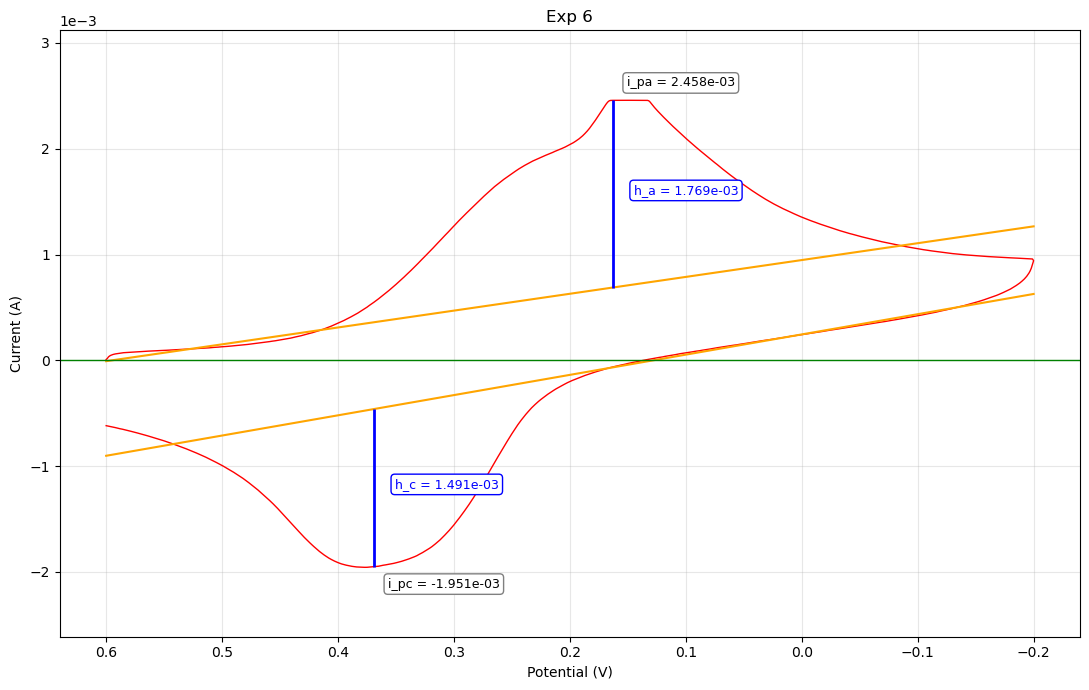

Analyzing Exp 7...


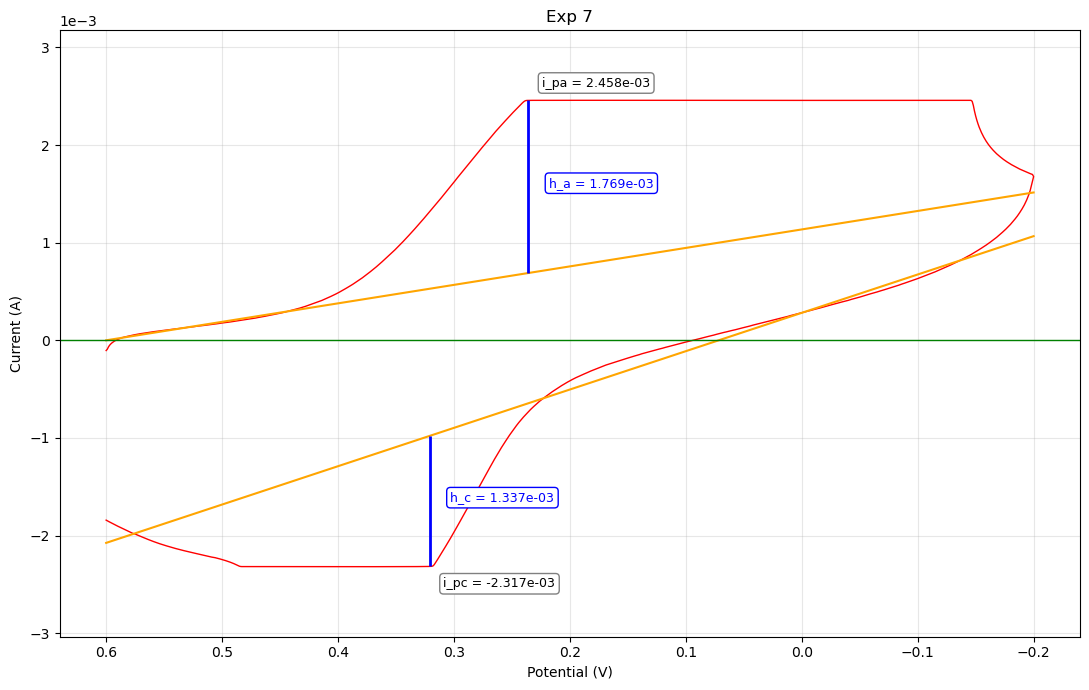

Analyzing Exp 8...


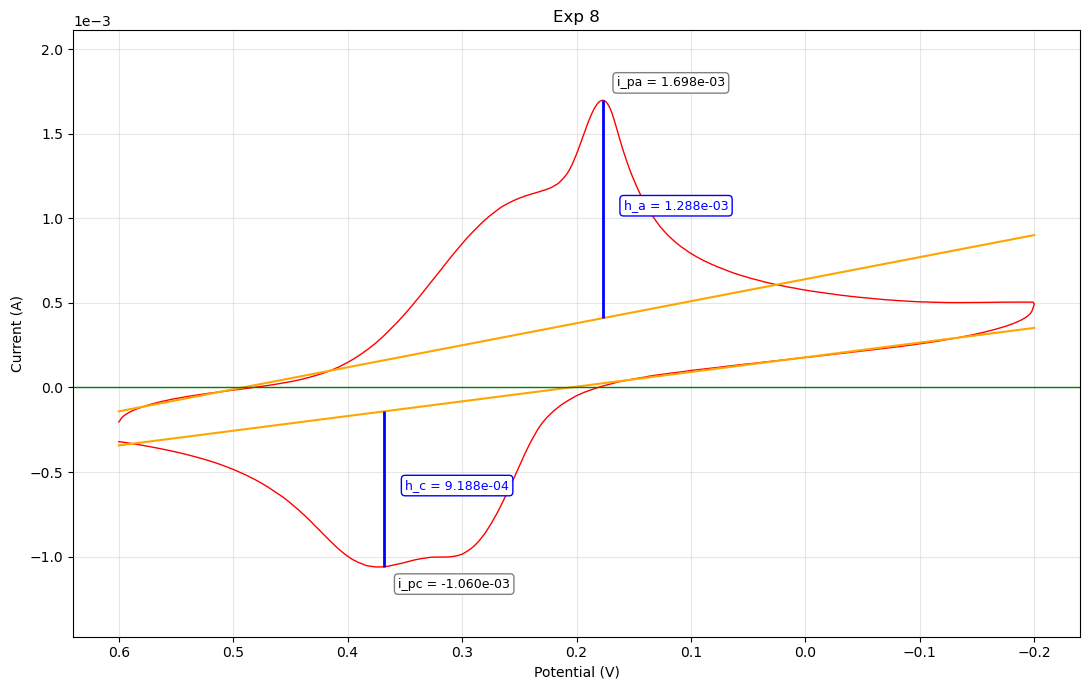

Analyzing Exp 9...


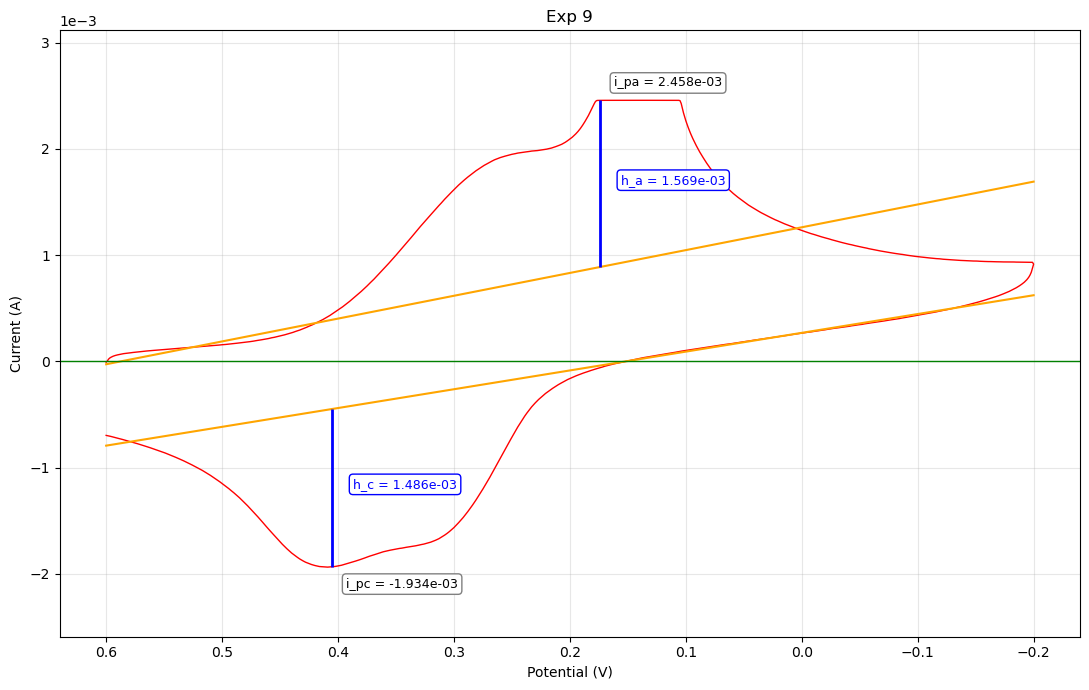

Analyzing exp 18...


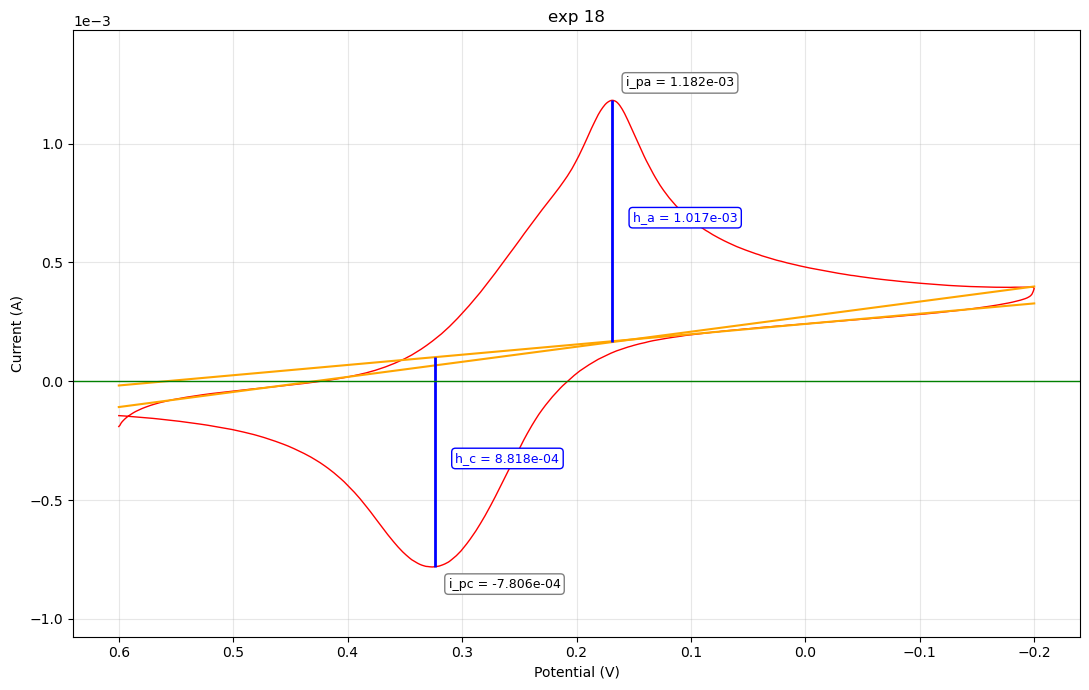

Analyzing exp 19...


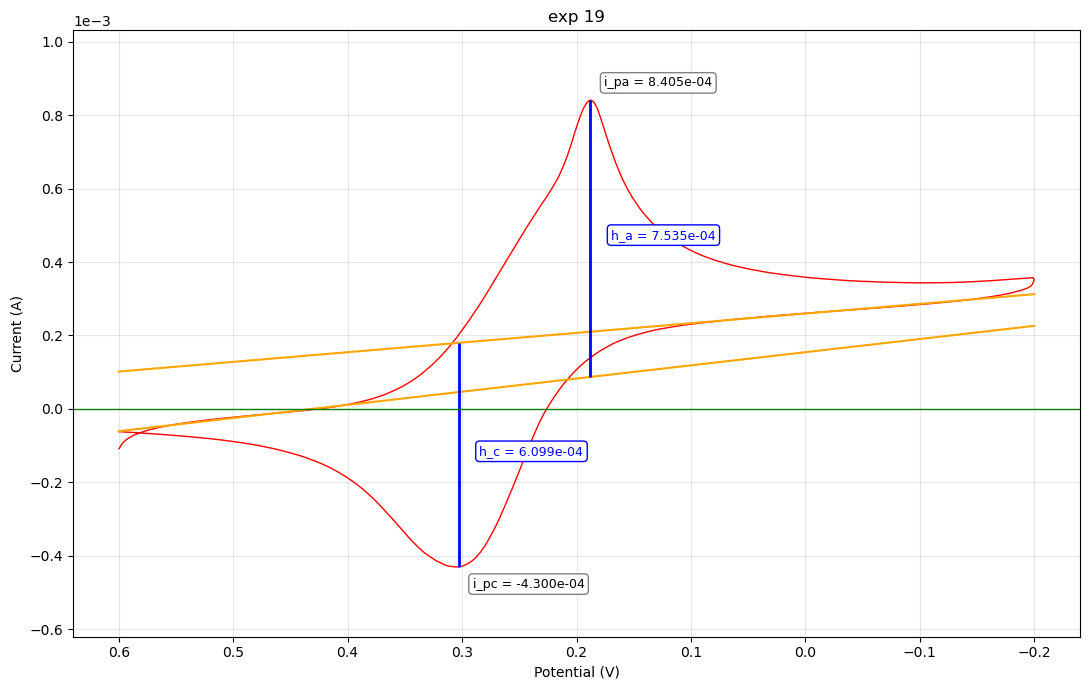


Done. 19/19 files analyzed.


In [144]:
from datetime import datetime

now = datetime.now()
formatted = now.strftime("%Y-%m-%d_%H-%M-%S")
csv_dir = os.path.join(CSV_DIR, formatted)
plot_dir = os.path.join(PLOT_DIR, formatted)
os.makedirs(csv_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

parsed = []
files = sorted([f for f in glob.glob(os.path.join(INPUT_DIR, '*'))
                if f.lower().endswith(('.csv', '.dy20'))])

for path in files:
    name = os.path.splitext(os.path.basename(path))[0]
    print(f'Parsing {name}...')
    try:
        df = load(path)
        df.to_csv(os.path.join(csv_dir, f'{name}.csv'), index=False)
        parsed.append((name, df))
    except Exception as e:
        print(f'  FAILED: {e}')

summary = []
for name, df in parsed:
    print(f'Analyzing {name}...')
    try:
        special = 'exp 10' in name.lower()
        res = analyze(df)
        plot_result(df, res, name, os.path.join(plot_dir, f'{name}.png'))
        summary.append({
            'File': name,
            'Anodic Peak Current (A)': res['i_pa'],
            'Anodic Peak Potential (V)': res['e_pa'],
            'Cathodic Peak Current (A)': res['i_pc'],
            'Cathodic Peak Potential (V)': res['e_pc'],
            'Anodic Peak Height (A)': res['anodic_height'],
            'Cathodic Peak Height (A)': res['cathodic_height'],
        })
    except Exception as e:
        print(f'  FAILED: {e}')

pd.DataFrame(summary).to_csv(os.path.join(csv_dir, 'peak_results.csv'), index=False)
print(f'\nDone. {len(summary)}/{len(parsed)} files analyzed.')

## Cell 8: Format and print results

In [145]:
results = pd.read_csv(RESULTS_CSV)
results.style.format({
    'Anodic Peak Current (A)': '{:.3e}',
    'Anodic Peak Potential (V)': '{:.3f}',
    'Cathodic Peak Current (A)': '{:.3e}',
    'Cathodic Peak Potential (V)': '{:.3f}',
    'Anodic Peak Height (A)': '{:.3e}',
    'Cathodic Peak Height (A)': '{:.3e}',
})

,File,Anodic Peak Current (A),Anodic Peak Potential (V),Cathodic Peak Current (A),Cathodic Peak Potential (V),Anodic Peak Height (A),Cathodic Peak Height (A)
0,Exp 1,2.057e-03,0.118,-1.683e-03,0.350,1.840e-03,1.295e-03
1,Exp 10,2.457e-03,0.273,-2.316e-03,0.314,1.724e-03,1.348e-03
2,Exp 11,1.718e-03,0.181,-1.028e-03,0.394,1.095e-03,8.658e-04
3,Exp 12,2.458e-03,0.178,-1.904e-03,0.419,1.306e-03,1.377e-03
4,Exp 13,2.458e-03,0.295,-2.316e-03,0.308,1.694e-03,1.360e-03
5,Exp 14,1.776e-03,0.184,-9.791e-04,0.409,1.037e-03,8.336e-04
6,Exp 15,2.458e-03,0.121,-2.189e-03,0.399,2.030e-03,1.737e-03
7,Exp 16,2.458e-03,0.148,-2.317e-03,0.365,1.869e-03,9.464e-04
8,Exp 17,1.651e-03,0.143,-1.279e-03,0.353,1.287e-03,1.215e-03
9,Exp 2,2.458e-03,0.132,-2.316e-03,0.359,2.128e-03,1.464e-03
